# The `fig,ax` pattern when plotting in Python

There's a major pattern for working with figures in Python with Matplotlib and its various derivative libraries, such as `pyplot`, `seaborn`, and the tools built-in to `pandas`.  Knowing this pattern will let you more easily work with plots.  

A word of caution: This is general advice, not a complete guide.  Some plotting calls and libaries have idiosyncrasies that make them work differently.  Not every plotting call will be immediately applicable to this pattern.  That doesn't devalue the pattern.  It just means you're never done learning!

## Overall pattern

The general steps are like this:

1. Make a figure and axis object.  Maybe make multiple axes, if doing side-by-side plotting.
2. Plot your data into the axes.  Adjust the labels, etc.
3. Save the figure to disk, or show it on screen.  I prefer saving to disk.

## 1. Some bob ross data

In [1]:
import matplotlib.pyplot as plt # canonical way to get ahold of pyplot.  

In [2]:
import pandas as pd

In [3]:
# import the data
bob_ross = pd.read_csv('elements-by-episode.csv')

I'll repeat some things from a Notebook from Lesson 6a.  I'll compute the number of elements that appeared in every episode.

First, I'll make a list of the columns I want to use, then I'll select those columns and do a row-wise sum

In [4]:
# a list comprehension with two conditionals to filter.
element_names = [c for c in bob_ross.columns if (c not in ['EPISODE','TITLE','DIANE_ANDRE','GUEST']) and ('FRAME' not in c)]

bob_ross['num_elements'] = bob_ross[element_names].sum(axis=1)

I want to plot the number of elements over time.  I can get a time axis from the `EPISODE` column.

In [5]:
bob_ross['season'] = bob_ross['EPISODE'].map(lambda s: int(s[1:3]))
bob_ross['episode_in_season'] = bob_ross['EPISODE'].map(lambda s: int(s[4:6]))

# not every season has the same number of episodes.
num_episodes_in_season = {s: (bob_ross[bob_ross['season']==s]).shape[0] for s in bob_ross['season'].unique()}

# I write a function to compute the absolute episode number.  
bob_ross['absolute_episode'] = bob_ross.apply(
    lambda row: row['episode_in_season'] 
                + 
                sum( [num_episodes_in_season[S] for S in range(1,row['season'])  ]) 
    ,axis=1)

# after writing this code, perhaps I could have simply made 
# the absolute episode number 1+index, but whatevs.  it was a good exercise.

# my method would work even if the data frame was not sorted by first season and then by episode...  

I'm going to plot the time series of number of elements (y-axis) vs episode number (x-axis), for the entire TV series.

1. I start by making a figure and axes from pyplot.  
2. Plot the data using existing axis object  
3. Save the figure I made.  File type is inferred from extension.
4. Since we're in Jupyter, the notebook automatically displays my plot.  Huzzah!

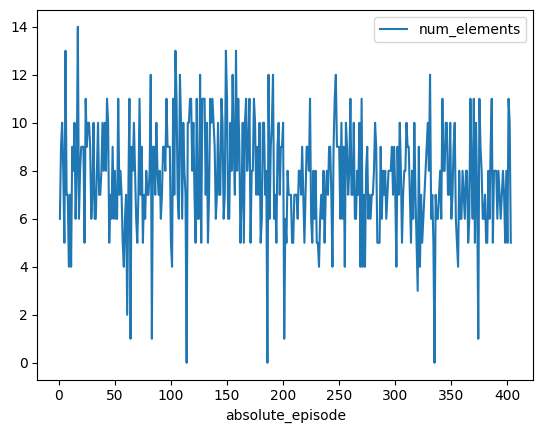

In [6]:
# 1. make a figure axis pair
fig, ax = plt.subplots(1,1)  # the 1,1 is the size of the array of axes to make.  increase to make a grid.

# 2. Plot
bob_ross.plot.line(x='absolute_episode', y='num_elements', ax=ax)

# 3. Save figure
fig.savefig('num_elements_complete_series.png',dpi=300, bbox_inches="tight")
                #                                        ^^^ makes figure not get cut off when saving

# 4. figure renders inline for free

Note that inline plotting is nice, but the resolution and size are not controlled.  I like saving figures, because I can use html to render the figure after saving, so that I get to control the resolution (dpi or dots per inch), and the size.  

Edit this cell to see how I included the graph using html.

<figure>
    <img src="./num_elements_complete_series.png", width=400>
    </figure>
    
⚠️ Due to caching in a browser, the image is not reloaded until you literally reload the page in your browser, so the refresh loop is difficult.  So using inline plotting in a Notebook has genuine value.

## Per-season data.  Explicit axis construction necessary

Ok, there's probably a way to do the following with just one plotting call, eliminating the loop and thus the need to have the axis around to re-use call-to-call, but I'm going to loop it.  


I think I'm ready to plot some per-season data.  

1. I start by making a figure and axes from pyplot.  
2. In a loop, I slice across season and plot into the axes I made.  
3. Saves the figure I made.
4. Since we're in Jupyter, the notebook automatically displays my plot.  Huzzah!

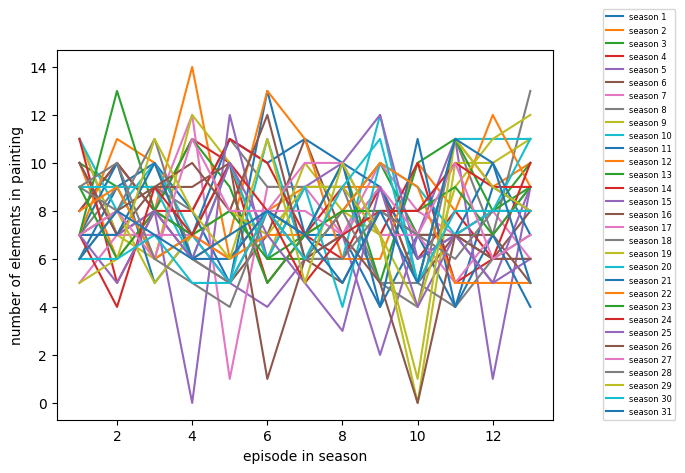

In [7]:
# 1. make a figure axis pair
fig, ax = plt.subplots(1,1)  # the 1,1 is the size of the array of axes to make.  increase to make a grid.

# 2. Loop and plot
for s in bob_ross['season'].unique():
    this_season = bob_ross[bob_ross['season']==s]
    this_season.plot.line(x='episode_in_season',y='num_elements', ax=ax, label=f'season {s}')
#                                                                  ^
#                                                                🔑 this makes plot into our axis, 
#                                                                instead of a new one every time

ax.set_ylabel('number of elements in painting')
ax.set_xlabel('episode in season')
plt.legend(loc=(1.10, 0), fontsize=6)


fig.savefig('elements_by_season.png', bbox_inches="tight", dpi=300) # 3.  Essential for .py files

Bob ross is super consistent across 31 seasons.  There are a few 0 entries, and I suspect that's because my column selection was not faithful.  Perhaps I dropped a column I shouldn't have.  

## Credits


This notebook prepared by silviana amethyst, phd, Spring 2023, Fall 2023